### Implementation of video 2:
### "Building makemore Part 2: MLP"
*(https://youtu.be/TCH_1BHY58I?si=K-3LdgqGDGu-z3Be)*

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('../data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
characters = sorted(list(set(''.join(words))))
s_to_i = {s:i+1 for i,s in enumerate(characters)}
s_to_i['.'] = 0
i_to_s = {i:s for s,i in s_to_i.items()}
print(i_to_s)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [87]:
# build dataset

block_size = 3
X, Y = [], []
# for w in words[:5]:
for w in words:

    # print(w)
    context = [0] * block_size
    for chr in w + '.':
        ix = s_to_i[chr]
        X.append(context)
        Y.append(ix)
        # print(''.join(i_to_s[i] for i in context), '---->', i_to_s[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [88]:
X.shape, X.dtype, Y.shape, Y.dtype

# output for first 5 words was:
# (torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
C = torch.randn((27, 2))

onehot encoding example

In [68]:
# C[5]

tensor([-0.4713,  0.7868])

In [69]:
# F.one_hot(torch.tensor([5]), num_classes=27)

tensor([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0]])

resuming with makemore

In [16]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [17]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [39]:
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)
h

tensor([[ 0.9929,  0.9816, -0.0930,  ...,  0.9131,  0.2873,  0.9526],
        [ 0.9939,  0.9939,  0.2931,  ...,  0.5229,  0.9135,  0.9523],
        [-0.9695, -0.7309, -0.9475,  ..., -0.7319,  0.4967,  0.1216],
        ...,
        [-0.9771, -0.9995, -0.9303,  ..., -0.9519, -0.6042, -0.2249],
        [ 0.9980,  0.0273, -0.9945,  ..., -0.2687,  0.3395,  0.9994],
        [-0.9820, -0.9990, -0.9924,  ..., -0.4120,  0.8709, -0.9927]])

In [40]:
h.shape

torch.Size([32, 100])

In [41]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [42]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [43]:
count = logits.exp()

In [45]:
prob = count / count.sum(1, keepdim=True)

prob.shape

torch.Size([32, 27])

In [50]:
loss = -prob[torch.arange(32), Y].log().mean()

loss

tensor(16.9736)

 Since we now know how to calculate 'loss', so we use that logic

In [89]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [139]:
# Initialize the parameters

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [140]:
sum(p.nelement() for p in parameters)

3481

In [141]:
"""
By default, tensors created via torch.randn() do not track gradients or participate in the computation graph. 
This means loss.backward() can't propagate gradients back to them, leading to an error:
"RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn"
"""

for p in parameters:
    p.requires_grad = True

In [142]:
# determining learning rate exponent
lre = torch.linspace(-3, 0, steps=1000)

lrs = 10**lre
# lrs

In [ ]:
lri= []
lossi = []

for i in range(1000):

    # mini-batch construct
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)

    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    
    # replace above logic (3 lines) with cross_entropy
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # # determine lre: track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())

# print(loss.item())

18.602834701538086
19.32079315185547
18.815750122070312
18.670202255249023
17.30464744567871
17.872716903686523
21.6412353515625
18.57143783569336
18.86028480529785
19.026710510253906
18.68102264404297
17.15528678894043
21.039133071899414
18.943645477294922
19.944561004638672
20.183313369750977
23.980140686035156
18.504728317260742
18.534263610839844
21.641984939575195
21.23460578918457
17.672048568725586
19.081127166748047
15.234519958496094
20.086158752441406
19.435787200927734
17.993894577026367
19.371850967407227
19.11085319519043
20.51893424987793
18.56753921508789
19.976451873779297
19.010955810546875
19.50824546813965
19.392318725585938
19.254117965698242
19.83938980102539
19.182544708251953
17.603532791137695
15.329628944396973
18.938371658325195
19.581819534301758
17.347877502441406
17.426769256591797
20.834596633911133
19.000652313232422
19.76304054260254
20.209426879882812
18.098434448242188
19.425437927246094
19.560266494750977
18.282503128051758
18.276033401489258
17.61167

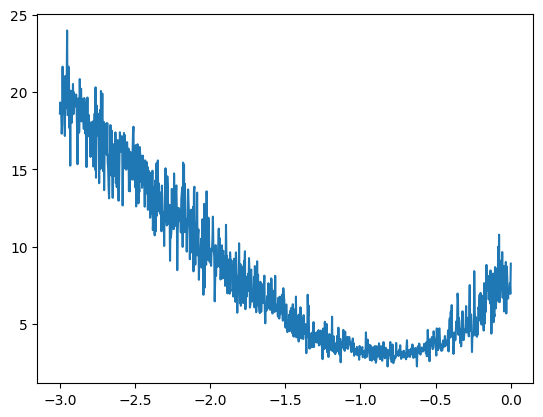

In [145]:
# determine lre:plotting the learning rate exponent vs loss
plt.plot(lri, lossi)